## 📊 Análisis de Ventas en el rubro Farmacéutico 
### Proyecto Final – Data Science

Autor/a: Rubis Becerra

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/processed/pharma_rsnx_processed.csv")

In [3]:
df.head(3)

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team,Sales_Level
0,Prohaska-Kuhic,"Wunsch, Mills and Walter",Kielce,Poland,50.8725,20.6319,Pharmacy,Institution,Tacrodomide,Antipiretics,10.0,420,4200.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low
1,Cassin,Block-Romaguera Pharmaceutical Limited,Tarnowskie Góry,Poland,50.4500,18.8667,Hospital,Private,Finanel,Antimalarial,20.0,206,4120.0,January,2018,Sheila Stones,Britanny Bold,Delta,Low
2,Smith Inc,Doyle-Tillman Pharmaceutical Ltd,Dęblin,Poland,51.5667,21.8614,Hospital,Private,Tacrodomide,Antipiretics,2.0,420,840.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distributor        5000 non-null   object 
 1   Customer Name      5000 non-null   object 
 2   City               5000 non-null   object 
 3   Country            5000 non-null   object 
 4   Latitude           5000 non-null   float64
 5   Longitude          5000 non-null   float64
 6   Channel            5000 non-null   object 
 7   Sub-channel        5000 non-null   object 
 8   Product Name       5000 non-null   object 
 9   Product Class      5000 non-null   object 
 10  Quantity           5000 non-null   float64
 11  Price              5000 non-null   int64  
 12  Sales              5000 non-null   float64
 13  Month              5000 non-null   object 
 14  Year               5000 non-null   int64  
 15  Name of Sales Rep  5000 non-null   object 
 16  Manager            5000 

### Feature Selection

In [5]:
# Se verifican algunas variables que pueden crear overfitting.
df["Product Name"].value_counts()

Product Name
Oxymotroban Fexoformin    33
Alisteride Pemidizem      33
Acelimus                  31
Nevanide Actozide         31
Adriacaine                30
                          ..
Zynosine                  13
Amphesirox                13
Arivac                    12
Relenstrel Exurabine      12
Methiclotide              10
Name: count, Length: 240, dtype: int64

In [6]:
# Se verifican algunas variables que pueden crear overfitting.
df.City.value_counts()

City
Neustadt        18
Bad Oldesloe    17
Offenburg       17
Gummersbach     16
Garbsen         16
                ..
Olsztyn          1
Krapkowice       1
Mysłowice        1
Łęczyca          1
Weinheim         1
Name: count, Length: 744, dtype: int64

In [7]:
# Se eliminan las variables que inicialmente por criterio no sumarían al modelo (identificadoras, jerárquicas y generar overfitting).
columnas_drop = [
    "Distributor", "Customer Name", "City", "Latitude", "Longitude", 
    "Product Name", "Name of Sales Rep", "Manager", "Sales_Level"
]
df_model = df.drop(columns=columnas_drop)

In [8]:
# Se filtran las ventas positivas.
df_model = df_model[df_model["Sales"] > 0]

In [9]:
# Se separan las variables numéricas y las categóricas.
numericas = df_model.select_dtypes(include=["int64", "float64"]).columns
categoricas = df_model.select_dtypes(include=["object"]).columns

# Se verifica la correlación de las variables numéricas que se había analizado en el EDA:
corr = df_model[numericas].corr()
corr["Sales"].sort_values(ascending=False)

Sales       1.000000
Quantity    0.752401
Price       0.117560
Year        0.026072
Name: Sales, dtype: float64

In [10]:
# Se aplica One-Hot Encoding para transformar variables categóricas en variables numéricas binarias.
# Se utiliza drop_first=True para evitar multicolinealidad perfecta y establecer una categoría base de comparación.
# Se establece que el valor final sea tipo entero (dtype=int).

df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)

In [11]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4955 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Quantity                        4955 non-null   float64
 1   Price                           4955 non-null   int64  
 2   Sales                           4955 non-null   float64
 3   Year                            4955 non-null   int64  
 4   Country_Poland                  4955 non-null   int64  
 5   Channel_Pharmacy                4955 non-null   int64  
 6   Sub-channel_Institution         4955 non-null   int64  
 7   Sub-channel_Private             4955 non-null   int64  
 8   Sub-channel_Retail              4955 non-null   int64  
 9   Product Class_Antibiotics       4955 non-null   int64  
 10  Product Class_Antimalarial      4955 non-null   int64  
 11  Product Class_Antipiretics      4955 non-null   int64  
 12  Product Class_Antiseptics       4955 no

### Modelo de Regresión Lineal Múltiple

#### Definición del problema:
El objetivo es construir un Modelo Predictivo de Sales.

Inicialmente se evaluarán dos especificaciones:  
- **Modelo 1** con Quantity  
- **Modelo 2** sin Quantity

In [12]:
# Por la asimetría y el modelo se aplica log.
df_model["Sales_log"] = np.log(df_model["Sales"])

### Modelo 1 de Regresión Lineal Múltiple con Quantity:

In [13]:
# Se separan las variables predictoras del target.
X = df_model.drop(["Sales", "Sales_log"], axis=1)
y = df_model["Sales_log"]

#### Metodología:

In [14]:
# Se separan las variables en 70% train y 30% test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
X_train

,Quantity,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,Product Class_Antimalarial,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
1920,12.0,688,2018,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4610,10.0,288,2020,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4391,10.0,106,2017,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2036,3.0,682,2019,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
112,10.0,536,2018,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,15.0,536,2018,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
467,20.0,430,2018,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3115,400.0,424,2019,0,1,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
3802,5.0,470,2018,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [16]:
# Se agrega la columna de la constante 1s (intercepto) solo al train.
X_train_const = sm.add_constant(X_train)

In [17]:
X_train_const

,const,Quantity,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
1920,1.0,12.0,688,2018,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
4610,1.0,10.0,288,2020,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4391,1.0,10.0,106,2017,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
2036,1.0,3.0,682,2019,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
112,1.0,10.0,536,2018,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,1.0,15.0,536,2018,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
467,1.0,20.0,430,2018,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3115,1.0,400.0,424,2019,0,1,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0
3802,1.0,5.0,470,2018,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [18]:
y_train

1920     9.018695
4610     7.965546
4391     6.966024
2036     7.623642
112      8.586719
          ...    
4461     8.992184
467      9.059517
3115    12.041198
3802     7.762171
861      8.453188
Name: Sales_log, Length: 3468, dtype: float64

In [19]:
# Se entrena el modelo 1.
model1 = sm.OLS(y_train, X_train_const).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              Sales_log   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     75.21
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:53:54   Log-Likelihood:                -6248.6
No. Observations:                3468   AIC:                         1.255e+04
Df Residuals:                    3441   BIC:                         1.272e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [20]:
# Se prepara el test agregando la constante.
X_test_const = sm.add_constant(X_test)

In [21]:
# Se predice en el test.
y_pred1 = model1.predict(X_test_const)

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred1))
mae = mean_absolute_error(y_test, y_pred1)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.4056707257829326
MAE: 1.1108026062967997


### Modelo 2 de Regresión Lineal Múltiple sin Quantity:

In [23]:
# Para el Modelo 2, se desestima la variable Quantity.
X_train_noQ = X_train.drop("Quantity", axis=1)
X_test_noQ = X_test.drop("Quantity", axis=1)

In [24]:
X_train_noQ

,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,Product Class_Antimalarial,Product Class_Antipiretics,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
1920,688,2018,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4610,288,2020,0,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4391,106,2017,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2036,682,2019,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
112,536,2018,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,536,2018,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
467,430,2018,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3115,424,2019,0,1,0,0,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
3802,470,2018,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1


In [25]:
X_test_noQ

,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,Product Class_Antimalarial,Product Class_Antipiretics,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
3154,745,2019,0,1,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2241,35,2018,0,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3317,782,2017,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2372,343,2019,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
168,64,2018,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,249,2019,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4408,517,2017,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4934,682,2020,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1321,490,2019,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [26]:
# Se agrega la columna de la constante 1s (intercepto) solo al train.
X_train_noQ_const = sm.add_constant(X_train_noQ)

In [27]:
X_train_noQ_const

,const,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,Product Class_Antimalarial,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
1920,1.0,688,2018,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4610,1.0,288,2020,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4391,1.0,106,2017,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2036,1.0,682,2019,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
112,1.0,536,2018,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,1.0,536,2018,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
467,1.0,430,2018,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3115,1.0,424,2019,0,1,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
3802,1.0,470,2018,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [28]:
y_train

1920     9.018695
4610     7.965546
4391     6.966024
2036     7.623642
112      8.586719
          ...    
4461     8.992184
467      9.059517
3115    12.041198
3802     7.762171
861      8.453188
Name: Sales_log, Length: 3468, dtype: float64

In [29]:
# Se entrena el modelo.
model2 = sm.OLS(y_train, X_train_noQ_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              Sales_log   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     38.75
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          1.56e-164
Time:                        17:53:54   Log-Likelihood:                -6598.9
No. Observations:                3468   AIC:                         1.325e+04
Df Residuals:                    3442   BIC:                         1.341e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [30]:
# Se prepara el test agregando la constante.
X_test_noQ_const = sm.add_constant(X_test_noQ)

In [31]:
X_test_noQ_const

,const,Price,Year,Country_Poland,Channel_Pharmacy,Sub-channel_Institution,Sub-channel_Private,Sub-channel_Retail,Product Class_Antibiotics,Product Class_Antimalarial,...,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Sales Team_Bravo,Sales Team_Charlie,Sales Team_Delta
3154,1.0,745,2019,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2241,1.0,35,2018,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
3317,1.0,782,2017,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2372,1.0,343,2019,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
168,1.0,64,2018,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,1.0,249,2019,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4408,1.0,517,2017,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4934,1.0,682,2020,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1321,1.0,490,2019,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [32]:
# Se predice en el test.
y_pred2 = model2.predict(X_test_noQ_const)

In [33]:
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mae2 = mean_absolute_error(y_test, y_pred2)

print("RMSE 2 Test:", rmse2)
print("MAE 2 Test:", mae2)

RMSE 2 Test: 1.5597376951712927
MAE 2 Test: 1.208849695425574


#### Conclusiones y Selección del Modelo de Predicción final:

Se estimaron dos especificaciones del modelo predictivo, una incluyendo la variable Quantity y otra excluyéndola. La evaluación fuera de muestra mostró que el modelo con Quantity presenta menores valores de RMSE y MAE, indicando un mejor desempeño estadístico en términos de error predictivo.

Sin embargo, dado que Sales se define como el producto de Price y Quantity, la inclusión de esta variable implica una relación mecánica con la variable dependiente. En un contexto de predicción ex-ante, donde la cantidad futura no es observable, su uso resulta metodológicamente inapropiado.

Por ello, se adopta como **"Modelo de Predicción final la especificación sin Quantity"** que aún con RMSE y MAE más altos, se considera como un modelo más consistente con un enfoque de predicción realista y aplicable.

In [34]:
# Una vez seleccionado el Modelo 2 de Regresión Lineal Múltiple sin Quantity, se predice train:
y_train_pred2 = model2.predict(X_train_noQ_const)

rmse2_train = np.sqrt(mean_squared_error(y_train, y_train_pred2))
mae2_train = mean_absolute_error(y_train, y_train_pred2)

print("RMSE 2 Train:", rmse2_train)
print("MAE 2 Train:", mae2_train)

RMSE 2 Train: 1.6223037347757912
MAE 2 Train: 1.2761799206716153


#### Conclusión de Resultados del Modelo de Predicción final:
Las métricas de error en entrenamiento y prueba son muy similares (train resultó ser levemente mayor a test), lo que indica que el modelo no presenta sobreajuste y mantiene una capacidad predictiva estable fuera de muestra.

RMSE 2 Train: 1.622   
MAE 2 Train: 1.276  

RMSE 2 Test: 1.560  
MAE 2 Test: 1.209
 
**RMSE diferencia ≈ 0.062**  
**MAE diferencia ≈ 0.067**

#### Diagnóstico del Modelo de Predicción final (sobre Train):

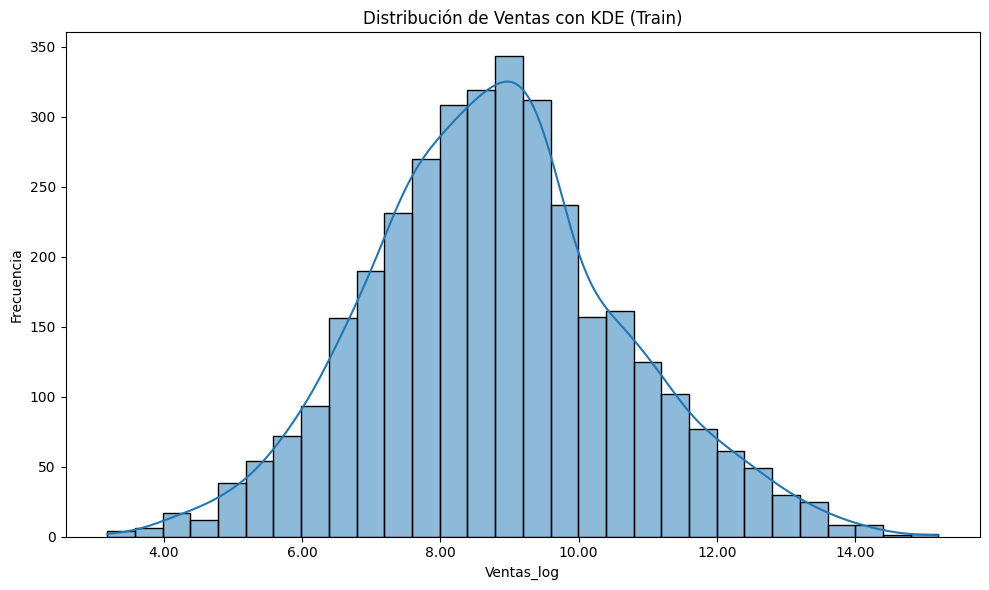

In [35]:
# Train: Se grafica la distribución de la variable "Sales" transformada.
plt.figure(figsize=(10,6))
sns.histplot(y_train, bins=30, kde=True)
plt.title("Distribución de Ventas con KDE (Train)")
plt.xlabel("Ventas_log")
plt.ylabel("Frecuencia")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.2f}"))
plt.tight_layout()
plt.show()

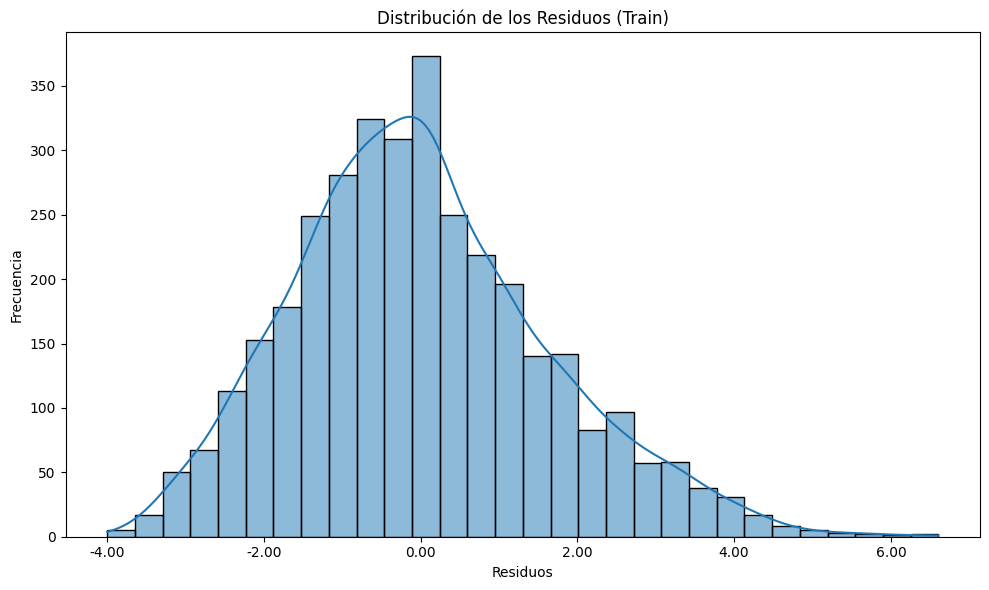

In [36]:
# Train: Se calculan y grafican los Residuos del modelo.
residuos = y_train - y_train_pred2

plt.figure(figsize=(10,6))
sns.histplot(residuos, bins=30, kde=True)
plt.title("Distribución de los Residuos (Train)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.2f}"))
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

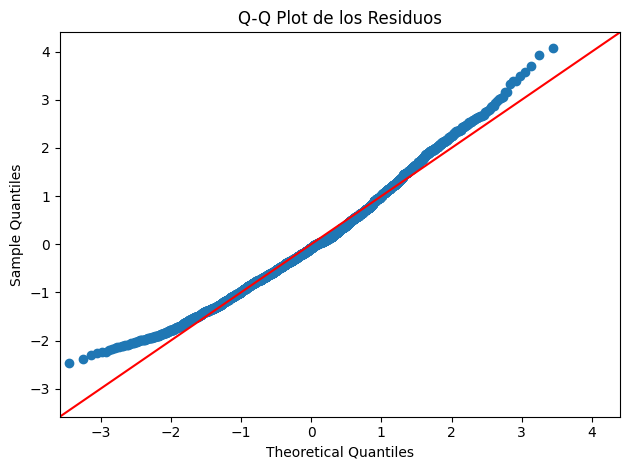

In [37]:
# Train: Gráfico Q-Q.
plt.figure(figsize=(10,6))
sm.qqplot(residuos, line='45', fit=True)
plt.title("Q-Q Plot de los Residuos")
plt.tight_layout()
plt.show()

#### Comentarios del gráfico Q-Q:
El gráfico Q-Q indica que los residuos se ajustan razonablemente a la distribución normal en la región central, observándose desviaciones moderadas en las colas. Estas diferencias no son severas y no comprometen la capacidad predictiva del modelo.

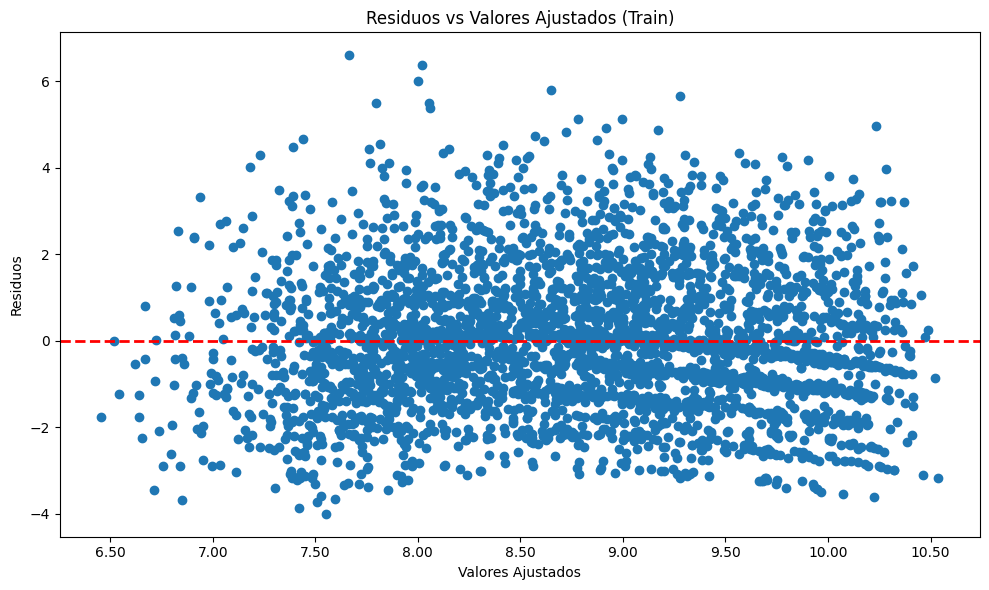

In [38]:
# Train: Gráfico de Residuos vs. Valores Ajustados.
plt.figure(figsize=(10,6))
plt.scatter(y_train_pred2, residuos)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title("Residuos vs Valores Ajustados (Train)")
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.2f}"))
plt.tight_layout()
plt.show()

#### Comentarios del gráfico Residuos vs Valores Ajustados:
Se visualiza una dispersión aleatoria de los errores alrededor de la línea horizontal en cero, sin evidencias claras de patrones sistemáticos. No se observa una forma de embudo pronunciada ni estructuras curvas que sugieran problemas de heterocedasticidad o no linealidad relevantes. La variabilidad de los residuos se mantiene relativamente constante a lo largo del rango de valores ajustados, lo que respalda el supuesto de homocedasticidad del modelo.